## 1. Stange's algorithm

### A slow but simple version

In [1]:
def order_number_rings(n, g, K, B=50, c=5, limit=1000, comments=False, PID_check=False):
    """
    INPUT:
    n = modulus
    g = base
    K = number field
    B = bound for the norm of the primes, i.e. N(primes) =< B
    c = number of additional relations
    limit = will search up to g^k, for k <= limit
    comments = run with print statements

    OUTPUT:
    (a multiple of) the order of g mod n

    This is done using a modified version of Stange's algorithm
    """

    if PID_check:
        if PID_check:
            if K.class_number() != 1:
                 raise Exeption("K is not a PID")

    # create the ring (Ok / (n))^x for 'mod n'
    OK = K.ring_of_integers()
    Kn = OK.quotient(K.ideal(n), 'b')

    # create a factor base
    FB = K.primes_of_bounded_norm(B)
    if comments:
        print(f"Finding a multiple of the order of {g} modulo {n}")
        print("Using the following factor base:")
        print(FB)

    def factor_by_FB(x, FB, K):
        """
        INPUT:
        x = element to factorise
        FB = factorbase
        K = number field

        OUTPUT:
        powers of the factorisation if found, None else

        This uses trial division over FB
        """

        # set up parameters
        I = K.ideal(x)
        powers = [0] * len(FB)
        FB_index = dict(zip(FB, range(len(FB))))

        # check for trivial element
        if I == K.ideal(1):
            return None

        # trial division
        # p.divides(I) is expensive so first a cheap test is used
        for p in FB:
            np = p.norm()
            # while p.divides(I):
            while ZZ(I.norm()) % np == 0 and p.divides(I):
                powers[FB_index[p]] += 1
                I = I / p

        # check if smooth over FB
        if I != K.ideal(1):
            return None

        return powers

    # set up parameters
    N = len(FB) + c 
    if comments:
        print(f"Searching for {N} relations")
    relations = []
    ks = []
    g_k = Kn(1)
    g = Kn(g)
    
    # compute g^k mod n and factorise
    # store if smooth over FB and new
    for k in range(1, limit + 1): 
        g_k *= g
        factorisation = factor_by_FB(g_k.lift(), FB, K)
        if factorisation != None:
        # if factorisation != None and not factorisation in relations:
            if comments: 
                print(f"found relation: g^{k} = {g_k.lift().factor()}")
            relations.append(factorisation)
            ks.append(k)
            N -= 1
        if N == 0: 
            if comments:
                print(f"found all relations at {k = }")
            break
    if N != 0 and comments:
        print(f"{limit = } reached, will likely fail")
    
    # Create matrix and compute the kernel 
    M = Matrix(ZZ, relations).transpose()
    kernel = M.right_kernel().basis()
    if comments:
        print("\nThe relation matrix:")
        print(M.str())
        print("The right kernel basis")
        print(kernel)
    
    # compute alpha's
    alphas = []
    for basis_v in kernel:
        alpha = basis_v * vector(ZZ, ks)
        alphas.append(alpha)
    if comments:
        print("\nFound the following values for alpha")
        print(alphas)
    # compute gcd
    final_gcd = 0
    for alpha in alphas:
        final_gcd = gcd(final_gcd, alpha)
    if comments:
        print(f"Thus a multiple of the order is {final_gcd}")

    return final_gcd

### A faster version 

In [2]:
# Faster version of code above
# The changes are in factor_by_FB
# and some check, e.g. "test" and assert g unit mod n

def order_number_rings(n, g, K, B=50, c=5, limit=1000, comments=False, PID_check=False, test = False):
    """
    INPUT:
    n = modulus
    g = base
    K = number field
    B = bound for the norm of the primes, i.e. N(primes) =< B
    c = number of additional relations
    limit = will search up to g^k, for k <= limit
    comments = run with print statements
    test = will assert that enough relations are found

    OUTPUT:
    (a multiple of) the order of g mod n

    This is done using a modified version of Stange's algorithm
    """
    # create the ring (Ok / (n))^x
    OK = K.ring_of_integers()
    Kn = OK.quotient(K.ideal(n), 'b')

    # checks for PID, existence of order and trivial case resp.
    if PID_check:
        assert K.class_number() == 1, "K is not a PID"

    assert K.ideal(g) + K.ideal(n) == K.ideal(1), "g is not a unit modulo (n)" 

    if Kn(g) == Kn(1):
        if comments:
            print("g is trivial, hence the order is 1")
        return 1

    # create a factor base
    FB = K.primes_of_bounded_norm(B)
    FB_gens  = [p.gens_reduced()[0] for p in FB]
    FB_norms = [ZZ(p.norm())        for p in FB]
    if comments:
        print(f"Finding a multiple of the order of {g} modulo {n}")
        print("Using the following factor base:")
        print(FB_gens)

    def factor_by_FB(x, FB_gens, FB_norms):
        """
        INPUT:
        x = element to factorise
        FB_gens = factorbase generators
        FB_norm = respective norms of generators

        OUTPUT:
        powers of the factorisation if found, None otherwise

        This uses trial division over the factorbase
        """

        # setup parameters and compute the norm
        x = K(x)
        x_norm = ZZ(x.norm()).abs()
        powers = [0] * len(FB_gens)

        # check if trivial/unit
        if x_norm <= 1:
            return None   

        # trial division for the generators
        for i, (gen, np) in enumerate(zip(FB_gens, FB_norms)):
            if x_norm % np != 0:
                continue
            while x_norm % np == 0:
                q = x / gen
                if not q.is_integral():
                    break
                x = OK(q)
                x_norm //= np
                powers[i] += 1
            if x_norm == 1:
                break

        if x_norm != 1:
            return None

        return powers

    # set up parameters
    N = len(FB) + c 
    if comments:
        print(f"Searching for {N} relations")
    relations = []
    ks = []
    g_k = Kn(1)
    g = Kn(g)
    
    # compute g^k mod n and factorise
    # store if smooth over FB
    for k in range(1, limit + 1): 
        g_k *= g
        lifted = g_k.lift()
        factorisation = factor_by_FB(OK(lifted), FB_gens, FB_norms)
        if factorisation != None:
            if comments: 
                print(f"found relation: g^{k} = {g_k.lift().factor()}")
            relations.append(factorisation)
            ks.append(k)
            N -= 1
        if N == 0: 
            if comments:
                print(f"found all relations at {k = }")
            break
    if N != 0 and comments:
        print(f"{limit = } reached, will likely fail")
    if test == True and N!= 0:
        assert N == 0, "not enough relations found"
    
    # create matrix and compute the kernel 
    M = Matrix(ZZ, relations).transpose()
    kernel = M.right_kernel().basis()
    if comments:
        print("\nThe relation matrix:")
        print(M.str())
        print("The right kernel basis")
        print(kernel)
    
    # compute alpha's
    alphas = []
    for basis_v in kernel:
        alpha = basis_v * vector(ZZ, ks)
        alphas.append(alpha)
    if comments:
        print("\nFound the following values for alpha")
        print(alphas)
        
    # compute gcd
    final_gcd = 0
    for alpha in alphas:
        final_gcd = gcd(final_gcd, alpha)
    if comments:
        print(f"Thus a multiple of the order is {final_gcd}")
    
    return final_gcd

# 2. Examples

In [3]:
K.<a> = NumberField(x^2 - 5)
n = 3
g = 3/2*a + 1/2

order_number_rings(n, g, K, B = 50, comments = True, PID_check = False)

Finding a multiple of the order of 3/2*a + 1/2 modulo 3
Using the following factor base:
[2, -a, 3, 3/2*a - 1/2, 3/2*a + 1/2, 2*a - 1, -2*a - 1, 1/2*a + 11/2, 1/2*a - 11/2, -5/2*a - 1/2, -5/2*a + 1/2, 1/2*a + 13/2, 1/2*a - 13/2, 7]
Searching for 19 relations
found relation: g^1 = 3/2*a + 1/2
found relation: g^2 = (-1) * (3/2*a + 1/2)
found relation: g^3 = 3/2*a + 1/2
found relation: g^4 = (-1) * (3/2*a + 1/2)
found relation: g^5 = 3/2*a + 1/2
found relation: g^6 = (-1) * (3/2*a + 1/2)
found relation: g^7 = 3/2*a + 1/2
found relation: g^8 = (-1) * (3/2*a + 1/2)
found relation: g^9 = 3/2*a + 1/2
found relation: g^10 = (-1) * (3/2*a + 1/2)
found relation: g^11 = 3/2*a + 1/2
found relation: g^12 = (-1) * (3/2*a + 1/2)
found relation: g^13 = 3/2*a + 1/2
found relation: g^14 = (-1) * (3/2*a + 1/2)
found relation: g^15 = 3/2*a + 1/2
found relation: g^16 = (-1) * (3/2*a + 1/2)
found relation: g^17 = 3/2*a + 1/2
found relation: g^18 = (-1) * (3/2*a + 1/2)
found relation: g^19 = 3/2*a + 1/2
foun

1

In [4]:
K.<a> = NumberField(x)
n = 100
g = 3

print(order_number_rings(n, g, K, B = 50, comments = True, PID_check = False))

Finding a multiple of the order of 3 modulo 100
Using the following factor base:
[2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47]
Searching for 20 relations
found relation: g^1 = 3
found relation: g^2 = 3^2
found relation: g^3 = 3^3
found relation: g^4 = (-1) * 19
found relation: g^5 = 43
found relation: g^6 = 29
found relation: g^7 = (-1) * 13
found relation: g^8 = (-1) * 3 * 13
found relation: g^9 = (-1) * 17
found relation: g^10 = 7^2
found relation: g^11 = 47
found relation: g^12 = 41
found relation: g^13 = 23
found relation: g^14 = (-1) * 31
found relation: g^15 = 7
found relation: g^16 = 3 * 7
found relation: g^17 = (-1) * 37
found relation: g^18 = (-1) * 11
found relation: g^19 = (-1) * 3 * 11
found relation: g^21 = 3
found all relations at k = 21

The relation matrix:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[1 2 3 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 1 1]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 2 0 0 0 0 1 1 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 

In [5]:
K.<a> = NumberField(x^3 - 17)
n = 1009
g = 1 + a

order_number_rings(n, g, K, B = 100, comments = True, PID_check = True, limit = 20000)

Finding a multiple of the order of a + 1 modulo 1009
Using the following factor base:
[1/3*a^2 + 2/3*a + 7/3, 1/3*a^2 + 2/3*a + 4/3, 1/3*a^2 - 4/3*a + 4/3, 1/3*a^2 - 1/3*a - 5/3, 2/3*a^2 + 1/3*a - 16/3, 2*a - 5, a, 1/3*a^2 + 2/3*a - 2/3, -11/3*a^2 - 28/3*a - 74/3, -a^2 - 2*a - 6, 2*a^2 + 5*a + 14, a - 4, 3*a - 8, a^2 - 2*a - 2, -2/3*a^2 + 5/3*a + 4/3, -8/3*a^2 - 19/3*a - 50/3, -a^2 + 6, -2/3*a^2 + 2/3*a + 1/3, 8/3*a^2 + 22/3*a + 53/3, 2/3*a^2 + 1/3*a + 2/3, -a^2 - 2*a + 12, -1/3*a^2 + 4/3*a - 10/3, -4/3*a^2 - 11/3*a - 22/3]
Searching for 28 relations
found relation: g^1 = (1/3*a^2 + 2/3*a + 7/3) * (1/3*a^2 + 2/3*a + 4/3) * (1/3*a^2 - 4/3*a + 4/3)
found relation: g^2 = (1/3*a^2 + 2/3*a + 7/3)^2 * (1/3*a^2 + 2/3*a + 4/3)^2 * (1/3*a^2 - 4/3*a + 4/3)^2
found relation: g^3 = (1/3*a^2 + 2/3*a + 7/3)^3 * (1/3*a^2 + 2/3*a + 4/3)^3 * (1/3*a^2 - 4/3*a + 4/3)^3
found relation: g^4 = (1/3*a^2 + 2/3*a + 7/3)^4 * (1/3*a^2 + 2/3*a + 4/3)^4 * (1/3*a^2 - 4/3*a + 4/3)^4
found relation: g^103 = (46291770

2887920

In [6]:
K.<a> = NumberField(x^3 - 17)
n = 1009
g = 1 + a

order_number_rings(n, g, K, B = 250, comments = True, PID_check = True, limit = 10000)

Finding a multiple of the order of a + 1 modulo 1009
Using the following factor base:
[1/3*a^2 + 2/3*a + 7/3, 1/3*a^2 + 2/3*a + 4/3, 1/3*a^2 - 4/3*a + 4/3, 1/3*a^2 - 1/3*a - 5/3, 2/3*a^2 + 1/3*a - 16/3, 2*a - 5, a, 1/3*a^2 + 2/3*a - 2/3, -11/3*a^2 - 28/3*a - 74/3, -a^2 - 2*a - 6, 2*a^2 + 5*a + 14, a - 4, 3*a - 8, a^2 - 2*a - 2, -2/3*a^2 + 5/3*a + 4/3, -8/3*a^2 - 19/3*a - 50/3, -a^2 + 6, -2/3*a^2 + 2/3*a + 1/3, 8/3*a^2 + 22/3*a + 53/3, 2/3*a^2 + 1/3*a + 2/3, -a^2 - 2*a + 12, -1/3*a^2 + 4/3*a - 10/3, -4/3*a^2 - 11/3*a - 22/3, -7/3*a^2 + 10/3*a + 20/3, 1/3*a^2 + 2/3*a + 16/3, 2/3*a^2 + 7/3*a + 8/3, -2*a + 3, -1/3*a^2 + 4/3*a + 8/3, -4/3*a^2 - 8/3*a - 19/3, -4*a^2 - 10*a - 25, 4/3*a^2 - 10/3*a + 1/3, -2*a - 1, 7/3*a^2 + 20/3*a + 46/3, 2*a + 3, 4/3*a^2 - 1/3*a - 26/3, -5/3*a^2 - 10/3*a - 26/3, 4/3*a^2 + 5/3*a - 38/3, -2/3*a^2 - 16/3*a + 55/3, -2*a^2 - 6*a - 15, -1/3*a^2 + 10/3*a - 22/3, 8*a^2 + 21*a + 54, a - 6, -6*a^2 - 15*a - 40, 2*a^2 - 3*a - 6, -a^2 + 8, -5/3*a^2 + 8/3*a + 10/3, 10/3*a^

756

In [7]:
K.<m> = NumberField(x^2 + 19)
n = 4*m + 75
g = m + 2

order_number_rings(n, g, K, B=50, comments=True, PID_check = True)

Finding a multiple of the order of m + 2 modulo 4*m + 75
Using the following factor base:
[2, -1/2*m + 1/2, 1/2*m + 1/2, 1/2*m + 3/2, 1/2*m - 3/2, 3, 1/2*m + 5/2, 1/2*m - 5/2, 1/2*m + 7/2, 1/2*m - 7/2, m, m - 2, -m - 2, 3/2*m + 1/2, -3/2*m + 1/2, 1/2*m + 13/2, 1/2*m - 13/2]
Searching for 22 relations
found relation: g^4 = (-1) * m * 2^4 * 3^3
found relation: g^7 = (-1) * m^3 * (-1/2*m + 1/2)^2 * (1/2*m + 1/2)^2 * 2
found relation: g^26 = (-1) * (-m - 2) * (m - 2) * m * 3^3
found relation: g^36 = (-1) * m^3 * (-1/2*m + 1/2) * (1/2*m + 1/2) * 2^2
found relation: g^51 = m^5 * 3
found relation: g^54 = m^3 * (-3/2*m + 1/2) * (3/2*m + 1/2)
found relation: g^57 = (1/2*m - 7/2) * m * (-1/2*m + 1/2) * (1/2*m + 1/2) * 2^4 * (1/2*m + 7/2)
found relation: g^65 = (-1) * m^3 * 2^3
found relation: g^75 = (-1) * (1/2*m - 7/2) * m * (-3/2*m + 1/2) * (3/2*m + 1/2) * 2^2 * (1/2*m + 7/2)
found relation: g^79 = (1/2*m - 7/2) * (-m - 2) * (m - 2) * m * (-1/2*m + 1/2) * (1/2*m + 1/2) * (1/2*m + 7/2)
found re

385

In [8]:
K.<a, b> = NumberField([x^2 + 2, x^2 - 2])
L.<c> = K.absolute_field()

n = 2*c + 13
g = c

order_number_rings(n, g, L, B=50, comments=True, PID_check=False)

Finding a multiple of the order of c modulo 2*c + 13
Using the following factor base:
[-1/4*c^2 + 1/2*c, -1/4*c^2 - 1/2*c + 1, -1/8*c^3 + 1/4*c^2 + 1/2*c, -1/8*c^3 + 2, 1/8*c^3 + 2, -1/2*c + 2, 1/2*c + 2, 1/4*c^2 + 2, 1/4*c^2 - 2, 1/8*c^3 - 1/2*c^2 - 1/2*c - 1, 1/8*c^3 + 1/2*c^2 - 1/2*c + 1, 1/8*c^3 + 1/4*c^2 + 1/2*c + 2, 1/8*c^3 - 1/4*c^2 + 1/2*c - 2, 1/2*c^2 - 1/2*c + 2, -1/2*c^2 - 1/2*c - 2]
Searching for 20 relations
found relation: g^3 = (35/2*c^2 + 99/2*c + 70) * (-1/4*c^2 + 1/2*c)^12
found relation: g^7 = (-40391/2*c^2 - 114243/2*c - 80782) * (-1/4*c^2 + 1/2*c)^28
found relation: g^11 = (46611179/2*c^2 + 131836323/2*c + 93222358) * (-1/4*c^2 + 1/2*c)^44
found relation: g^34 = (3*c^2 + 17/2*c + 12) * (-1/4*c^2 + 1/2*c)^8 * (-1/4*c^2 - 1/2*c + 1)^6 * (-1/8*c^3 + 1/4*c^2 + 1/2*c)^6
found relation: g^75 = (99/8*c^3 + 35/2*c^2 - 70) * (-1/4*c^2 + 1/2*c)^12 * (1/4*c^2 + 2)^3 * (1/4*c^2 - 2)^3 * (1/2*c^2 - 1/2*c + 2) * (-1/2*c^2 - 1/2*c - 2)
found relation: g^78 = (-3/2*c^3 + 6*c + 17)

1801

In [9]:
K.<z> = CyclotomicField(3)

n = 13 + 11*z
g = 2*z + 8

order_number_rings(n, g, K, c=5, comments = True, PID_check = True, B=50)

Finding a multiple of the order of 2*z + 8 modulo 11*z + 13
Using the following factor base:
[z - 1, 2, -3*z - 2, 3*z + 1, z + 4, z - 3, 2*z - 3, -2*z - 5, 5, z + 6, z - 5, 3*z - 4, -3*z - 7, z + 7, z - 6]
Searching for 20 relations
found relation: g^1 = (-z) * 2 * 5^2
found relation: g^3 = (-z) * (z - 5) * (z + 6)
found relation: g^5 = (z) * (-2*z - 5) * (2*z - 3)
found relation: g^7 = (-z) * 2 * 5^2
found relation: g^9 = (-z) * (z - 5) * (z + 6)
found relation: g^11 = (z) * (-2*z - 5) * (2*z - 3)
found relation: g^13 = (-z) * 2 * 5^2
found relation: g^15 = (-z) * (z - 5) * (z + 6)
found relation: g^17 = (z) * (-2*z - 5) * (2*z - 3)
found relation: g^19 = (-z) * 2 * 5^2
found relation: g^21 = (-z) * (z - 5) * (z + 6)
found relation: g^23 = (z) * (-2*z - 5) * (2*z - 3)
found relation: g^25 = (-z) * 2 * 5^2
found relation: g^27 = (-z) * (z - 5) * (z + 6)
found relation: g^29 = (z) * (-2*z - 5) * (2*z - 3)
found relation: g^31 = (-z) * 2 * 5^2
found relation: g^33 = (-z) * (z - 5) * (z +

6

In [10]:
K.<z> = CyclotomicField(3)

n = 13 + 11*z
g = 2*z + 8

order_number_rings(n, g, K, c=0, comments = True, PID_check = True, B=19)

Finding a multiple of the order of 2*z + 8 modulo 11*z + 13
Using the following factor base:
[z - 1, 2, -3*z - 2, 3*z + 1, z + 4, z - 3, 2*z - 3, -2*z - 5]
Searching for 8 relations
found relation: g^5 = (z) * (-2*z - 5) * (2*z - 3)
found relation: g^11 = (z) * (-2*z - 5) * (2*z - 3)
found relation: g^17 = (z) * (-2*z - 5) * (2*z - 3)
found relation: g^23 = (z) * (-2*z - 5) * (2*z - 3)
found relation: g^29 = (z) * (-2*z - 5) * (2*z - 3)
found relation: g^35 = (z) * (-2*z - 5) * (2*z - 3)
found relation: g^41 = (z) * (-2*z - 5) * (2*z - 3)
found relation: g^47 = (z) * (-2*z - 5) * (2*z - 3)
found all relations at k = 47

The relation matrix:
[0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0]
[1 1 1 1 1 1 1 1]
[1 1 1 1 1 1 1 1]
The right kernel basis
[
(1, 0, 0, 0, 0, 0, 0, -1),
(0, 1, 0, 0, 0, 0, 0, -1),
(0, 0, 1, 0, 0, 0, 0, -1),
(0, 0, 0, 1, 0, 0, 0, -1),
(0, 0, 0, 0, 1, 0, 0, -1),
(0, 0, 0, 0, 0, 1, 0, -1),
(0, 0, 0, 0, 0, 0, 1

6

# 3. Shor's reduction

### GCD

In [11]:
def my_gcd(a, b, K, f=lambda x: abs(x.norm())):
    """
    INPUT:
    a    = element in k
    b    = element in k
    K    = number field
    f    = a Euclidean function
    OUTPUT:
    gcd of a, b as ideal
    """
    # ensure input is sensible and set up parameters
    assert K.is_euclidean_domain(), 'K is not euclidean'
    OK = K.ring_of_integers()
    a, b = OK(a), OK(b)

    # Euclidean algorithm
    while b != 0:
        q_field = K(a) / K(b)
        coords = q_field.list()
        # just q = OK(K(a/b)).round() does not work
        q = OK(sum(QQ(c).round() * OK.basis()[i] for i, c in enumerate(coords)))
        r = OK(a - q * b)
        a, b = b, r

    return K.ideal(a)

In [12]:
def my_gcd(a, b, K):
    """
    INPUT:
    a = element in K
    b = element in K
    K = number field

    OUTPUT:
    gcd of ideals (a) and (b), i.e. (a) + (b)
    """
    return K.ideal(a) + K.ideal(b)

In [13]:
# The gcd functions give different representative for their result.

K.<a> = NumberField(x^2 - 3)
my_gcd(-15*a + 1, 20*a + 2, K)

Fractional ideal (a + 1)

### Shor's reduction

In [14]:
import random

def shor(n, K, B = 50, c = 5, limit= 15, comments = False, order_limit = 1000):
    """
    INPUT:
    n        = element in number ring to factorise
    K        = number field
    limit    = integer, bound on generating g
    B, c, orderlimit = parameters for order_number_rings
    comments = run with print statements

    OUTPUT:
    a factorisation of n

    Using Shor's reduction
    """
    
    # enusre n has nontrivial factors
    OK = K.ring_of_integers()
    assert not OK(n).is_unit(), "n is a unit"

    # set up parameters
    Kn = OK.quotient(K.ideal(n), 'b')
    poss_g = [(a, b) for a in range(-limit, limit) 
                         for b in range(1, limit)
                         if not (a == 0 and b <= 1)]
    #random.seed(int(42))
    random.shuffle(poss_g)
    poss_g = poss_g[:10]
    failed_orders = 0

    # loop Shor's reduction
    for (a, b) in poss_g:
        g = a*K.gen() + b
        g_bar = Kn(OK(g))
        if comments:
            print(f"starting the loop with {g = }")

        if my_gcd(g, n, K) != K.ideal(1) and K.ideal(n) != my_gcd(g, n, K):
            return my_gcd(g, n, K), n / my_gcd(g, n, K)
        
        # compute order, ignore when g is zero
        try:
            order = order_number_rings(n, g, K, B= B, c = c, test = True, comments = comments, limit = order_limit)
            if order == 0:
                continue
        except:
            continue

        if comments:
            print(f"for {g = } a order was computed succesfully, namely {order = }")

        if order % 2 == 0 and g_bar^(order // 2) != Kn(K(-1)):
            return my_gcd(g^(order // 2) - 1, n, K), n / my_gcd(g^(order // 2) - 1, n, K)
        
        failed_orders += 1
        if comments:
            print(f"order {order} unusable, {failed_orders} failed orders")
        if failed_orders >= 4:
            raise RuntimeError(f"shor() failed: 4 usable orders found but none led to a factorisation of {n}")
        
    if comments:
        print(f"no suitable g found for {limit = }")

In [15]:
def shor_factor_completely(n, K, B=50, c=5, order_limit=10000, comments = False):
    """
    INPUT:
    n           = element to factor
    K           = number field
    Comments    = run with comments
    B, c, order_limit = parameters for shor

    OUTPUT:
    complete factorization of n, in prime ideals
    
    Recursively factor K.ideal(n) into prime ideals using shor.
    """
    def _split(ideal):
        """
        spltis an ideal into two factors using shor
        """
        if ideal.is_prime():
            return [ideal]
        gens = ideal.gens_reduced()
        elem = gens[0] if len(gens) == 1 else K.ring_of_integers()(ideal.norm())

        result = shor(elem, K, B=B, c=c, comments=comments, order_limit=order_limit)
        if result is None:
            raise RuntimeError(f"shor() could not split {ideal}")

        fac1, fac2 = result
        return _split(fac1) + _split(fac2)

    return _split(K.ideal(n))

## Examples

In [16]:
K.<a> = NumberField(x^2 - 3)
n = 20*a + 2

shor(n, K, comments = True)

starting the loop with g = 9*a + 9


(Fractional ideal (a + 1), Fractional ideal (-9*a + 29))

In [17]:
n = -47*a + 85
shor(n, K, comments = True)

starting the loop with g = 7*a + 11


(Fractional ideal (a + 1), Fractional ideal (10*a + 1))

In [19]:
K.<b> = CyclotomicField(4)
n = 30 + 1 * b

shor(n, K, comments = True)

starting the loop with g = -7*b + 8
Finding a multiple of the order of -7*b + 8 modulo b + 30
Using the following factor base:
[b - 1, 2*b - 1, -2*b - 1, 3, 3*b + 2, -2*b - 3, b + 4, b - 4, 2*b - 5, -2*b - 5, b + 6, b - 6, 5*b + 4, -4*b - 5, 7]
Searching for 20 relations
found relation: g^2 = (-2*b - 3)^2 * (b - 1)^2 * (3*b + 2)^2
found relation: g^4 = (-b) * (b - 1)^4 * 3 * 7
found relation: g^6 = (-b) * (-2*b - 1) * (2*b - 1) * 3^2 * 7
found relation: g^15 = (b) * (-2*b - 1) * (2*b - 1) * 7^2
found relation: g^17 = (-b) * 3^5
found relation: g^18 = (-b) * (b - 6) * (-2*b - 1) * (2*b - 1) * (b + 6)
found relation: g^20 = (b - 1)^2 * 3^2
found relation: g^21 = (b) * (-2*b - 1) * (b - 1)^12 * (2*b - 1)
found relation: g^25 = (b) * (-2*b - 1) * (2*b - 1)
found relation: g^26 = (b) * 3^3 * 7
found relation: g^29 = (-1) * (b - 1)^2 * 7
found relation: g^34 = (-b) * (-2*b - 3) * (b - 1)^6 * (3*b + 2)
found relation: g^35 = (-b) * 3 * 7^2
found relation: g^36 = (-b) * (-2*b - 3) * (-2*b - 1)

(Fractional ideal (-2*b - 7), Fractional ideal (b - 4))

In [20]:
K.<a> = NumberField(x^3 - 17)
n = 12345678

shor(n, K, comments = True, order_limit = 100000)

starting the loop with g = -15*a + 10
Finding a multiple of the order of -15*a + 10 modulo 12345678
Using the following factor base:
[1/3*a^2 + 2/3*a + 7/3, 1/3*a^2 + 2/3*a + 4/3, 1/3*a^2 - 4/3*a + 4/3, 1/3*a^2 - 1/3*a - 5/3, 2/3*a^2 + 1/3*a - 16/3, 2*a - 5, a, 1/3*a^2 + 2/3*a - 2/3, -11/3*a^2 - 28/3*a - 74/3, -a^2 - 2*a - 6, 2*a^2 + 5*a + 14, a - 4]
Searching for 17 relations
found relation: g^1 = (-1) * (-11/3*a^2 - 28/3*a - 74/3) * (2/3*a^2 + 1/3*a - 16/3) * (2*a - 5) * (2*a^2 + 5*a + 14)
found relation: g^2 = (-11/3*a^2 - 28/3*a - 74/3)^2 * (2/3*a^2 + 1/3*a - 16/3)^2 * (2*a - 5)^2 * (2*a^2 + 5*a + 14)^2
found relation: g^3 = (-1) * (-11/3*a^2 - 28/3*a - 74/3)^3 * (2/3*a^2 + 1/3*a - 16/3)^3 * (2*a - 5)^3 * (2*a^2 + 5*a + 14)^3
limit = 100000 reached, will likely fail
starting the loop with g = 7*a + 4


(Fractional ideal (a - 2),
 Fractional ideal (1371742*a^2 + 2743484*a + 5486968))

# 4. Ideal factorisation

In [21]:
## minor modification to the original
## most important one is in factor_by_FB


def order_number_rings_ideals(n, g, K, B=50, c=5, limit=1000, comments=False, PID_check=False, test = False):
    """
    INPUT:
    n = modulus
    g = base
    K = number field
    B = bound for the norm of the primes, i.e. N(primes) =< B
    c = number of additional relations
    limit = will search up to g^k, for k <= limit
    comments = run with print statements
    test = will assert that enough relations are found

    OUTPUT:
    (a multiple of) the order of g mod n

    This is done using a modified version of Stange's algorithm
    """
    # create the ring (Ok / (n))^x
    OK = K.ring_of_integers()
    Kn = OK.quotient(K.ideal(n), 'b')

    # checks for PID, existence of order and trivial case resp.
    if PID_check:
        assert K.class_number() == 1, "K is not a PID"

    assert K.ideal(g) + K.ideal(n) == K.ideal(1), "g is not a unit modulo (n)" 

    if Kn(g) == Kn(1):
        if comments:
            print("g is trivial, hence the order is 1")
        return 1

    # create a factor base
    FB = K.primes_of_bounded_norm(B)
    FB_norms = [ZZ(p.norm())        for p in FB]
    if comments:
        print(f"Finding a multiple of the order of {g} modulo {n}")
        print("Using the following factor base:")
        print(FB)

    def factor_by_FB(x, FB, OK, K):
        """
        INPUT:
        x = element to factorise
        FB = factor base
        OK = ring of integers of K
        K = number field

        OUTPUT:
        powers of the factorisation if found, None else

        This uses trial division over FB
        """
        I = K.ideal(x)
        if I == K.ideal(1):
            return None
        powers = [0] * len(FB)
        for i, p in enumerate(FB):
            if ZZ(I.norm()) % FB_norms[i] != 0:
                continue
            while p.divides(I):
                powers[i] += 1
                I = I / p
        if I != K.ideal(1):
            return None
        return powers

    # set up parameters
    N = len(FB) + c 
    if comments:
        print(f"Searching for {N} relations")
    relations = []
    ks = []
    g_k = Kn(1)
    g = Kn(g)
    
    # compute g^k mod n and factorise
    # store if smooth over FB
    for k in range(1, limit + 1): 
        g_k *= g
        lifted = g_k.lift()
        factorisation = factor_by_FB(OK(lifted), FB, OK, K)
        if factorisation != None:
            if comments: 
                print(f"found relation: g^{k} = {g_k.lift().factor()}")
            relations.append(factorisation)
            ks.append(k)
            N -= 1
        if N == 0: 
            if comments:
                print(f"found all relations at {k = }")
            break
    if N != 0 and comments:
        print(f"{limit = } reached, will likely fail")
    if test == True and N!= 0:
        assert N == 0, "not enough relations found"
    
    # create matrix and compute the kernel 
    M = Matrix(ZZ, relations).transpose()
    kernel = M.right_kernel().basis()
    if comments:
        print("\nThe relation matrix:")
        print(M.str())
        print("The right kernel basis")
        print(kernel)
    
    # compute alpha's
    alphas = []
    for basis_v in kernel:
        alpha = basis_v * vector(ZZ, ks)
        alphas.append(alpha)
    if comments:
        print("\nFound the following values for alpha")
        print(alphas)
        
    # compute gcd
    final_gcd = 0
    for alpha in alphas:
        final_gcd = gcd(final_gcd, alpha)
    if comments:
        print(f"Thus a multiple of the order is {final_gcd}")
    
    return final_gcd

## Example

In [22]:
K.<z> = CyclotomicField(3)

n = 11031 + 9987*z   
g = z + 4

order_number_rings_ideals(n, g, K, c=5, comments=True, PID_check=True, B=200, limit=50000)

Finding a multiple of the order of z + 4 modulo 9987*z + 11031
Using the following factor base:
[Fractional ideal (z - 1), Fractional ideal (2), Fractional ideal (-3*z - 2), Fractional ideal (3*z + 1), Fractional ideal (z + 4), Fractional ideal (z - 3), Fractional ideal (2*z - 3), Fractional ideal (-2*z - 5), Fractional ideal (5), Fractional ideal (z + 6), Fractional ideal (z - 5), Fractional ideal (3*z - 4), Fractional ideal (-3*z - 7), Fractional ideal (z + 7), Fractional ideal (z - 6), Fractional ideal (4*z - 5), Fractional ideal (-4*z - 9), Fractional ideal (2*z - 7), Fractional ideal (-2*z - 9), Fractional ideal (z + 9), Fractional ideal (z - 8), Fractional ideal (3*z - 7), Fractional ideal (-3*z - 10), Fractional ideal (3*z + 11), Fractional ideal (-3*z + 8), Fractional ideal (2*z - 9), Fractional ideal (-2*z - 11), Fractional ideal (-5*z - 12), Fractional ideal (-5*z + 7), Fractional ideal (11), Fractional ideal (6*z - 7), Fractional ideal (-6*z - 13), Fractional ideal (3*z - 10

650622

# 5. Comparison

In [24]:
import time
import matplotlib.pyplot as plt
import numpy as np

def compare_factorisation_grid(m_values, vals_per_field, B=[50], c=[5], order_limit=[100000], comments=False):
    """
    INPUT:
    m_values        = list of values for which Q(zeta_m) is used
    vals_per_field  = pair for which n = a*zeta_m + b, will be factorised
    B, c            = list of parameters, zipped with m_values (one (B,c) per m)
    order_limit     = list of parameters, zipped with m_values (one per m)
    comments        = run with comments
    OUTPUT:
    a set containing m, time using shor_factor_completely, time using .factor() with B,c - values
    """
    def compare_factorisation(m_values, vals_per_field, B=50, c=5, order_limit=100000, comments=False):
        results = {}
        for m in m_values:
            K = CyclotomicField(m)
            z = K.gen()
            norms, shor_times, sage_times = [], [], []
            for (a, b) in vals_per_field:
                n = a*z + b
                norm_n = ZZ(K.ideal(n).norm())
                t0 = time.time()
                try:
                    shor_factor_completely(n, K, B=B, c=c, order_limit=order_limit, comments=comments)
                    shor_t = time.time() - t0
                except Exception as e:
                    if comments:
                        print(f"  shor failed for n={n}: {e}")
                    shor_t = float('nan')
                t0 = time.time()
                K.ideal(n).factor()
                sage_t = time.time() - t0
                norms.append(norm_n)
                shor_times.append(shor_t)
                sage_times.append(sage_t)
            results[m] = {'norms': norms, 'shor': shor_times, 'sage': sage_times}
        return results

    results = {}

    for m, Bv, cv, olv in zip(m_values, B, c, order_limit):
        run = compare_factorisation([m], vals_per_field, B=Bv, c=cv, order_limit=olv, comments=comments)
        results[m] = {(Bv, cv): run[m]}

    return results

In [25]:
# obtain data for plot
# most of the time waiting (>90%) is used for failing to split 2 in Q(zeta_7)

m_vals = [3, 5, 7]
n_vals = [(1, 4), (3, 5),(6, 8), (2, 12), (8, 21), (34, 18), (14, 71), (98, 66)]
B = [30, 75, 250]
c = [4, 4, 4]
order_limit = [1000, 5000, 5000]

data = compare_factorisation_grid(m_vals, n_vals, B=B, c=c, order_limit=order_limit, comments = False)

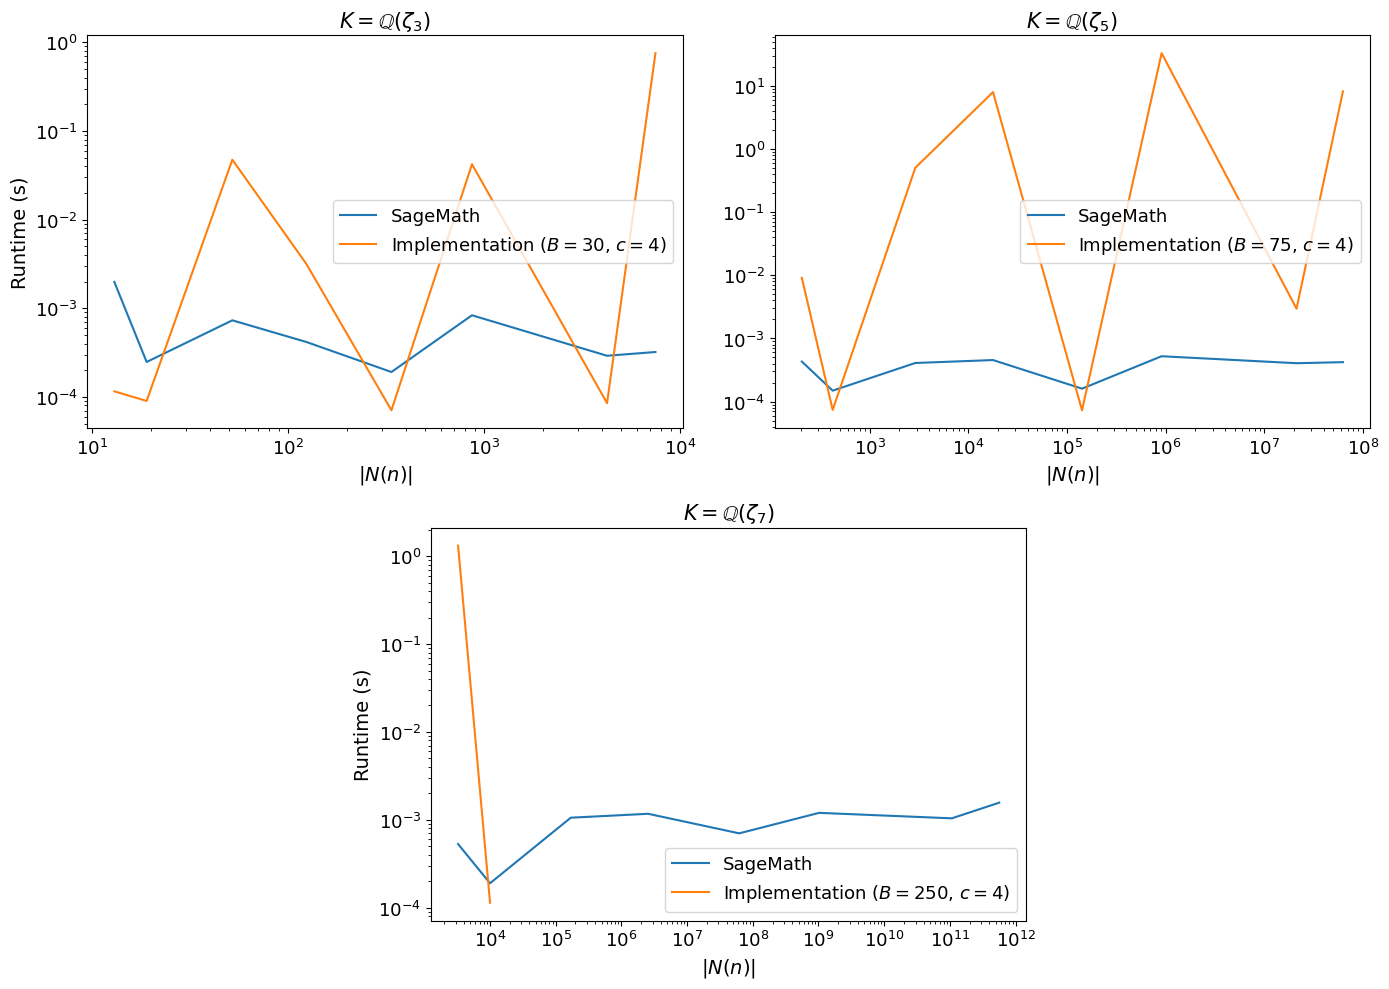

In [27]:
# create plot
bc_pairs = list(zip(m_vals, B, c))
fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(2, 4)
axes = [
    fig.add_subplot(gs[0, :2]),
    fig.add_subplot(gs[0, 2:]),
    fig.add_subplot(gs[1, 1:3]),
]
positions = ['center right', 'center right', 'lower right']

for ax, (m, Bv, cv), pos in zip(axes, bc_pairs, positions):
    d = data[m][(Bv, cv)]
    ax.plot(d['norms'], d['sage'], label="SageMath")
    ax.plot(d['norms'], d['shor'], label=f"Implementation ($B={Bv}$, $c={cv}$)")
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'$|N(n)|$', fontsize=14)
    ax.set_title(r'$K = \mathbb{Q}(\zeta_{' + str(m) + r'})$', fontsize=15)
    ax.legend(fontsize=13, loc=pos)
    ax.tick_params(axis='both', labelsize=13)
axes[0].set_ylabel('Runtime (s)', fontsize=14)
axes[2].set_ylabel('Runtime (s)', fontsize=14)
#fig.suptitle("Factorisation runtime: Stange's Algorithm + Shor's reduction vs SageMath's .factor()", fontsize=18)
plt.tight_layout()
plt.show()

## Debug

In [ ]:
def debug_order(n, g, K):
    """
    INPUT: n, g, k
    OUTPUT: bruteforced answer
    """
    OK = K.ring_of_integers()
    Kn = OK.quotient(K.ideal(n), 'b')

    g_Kn = Kn(g)
    g_k  = Kn(1)

    for k in range(1, 100000):
        g_k *= g_Kn
        if g_k == Kn(1):
            return k

In [ ]:
def debug_factorisation(n, K):
    """
    INPUT: n, K
    OUTPUT: Sage's sol
    """
    OK = K.ring_of_integers()
    return OK(n).factor()